# TTM vs Traditional Forecasters — Synthetic ARIMA(3,0,3)

Tests TTM (zero-shot) against traditional forecasters on a synthetic ARIMA(3,0,3) series. Since the true DGP is a linear ARMA model, this is a stress test where traditional forecasters have the home-field advantage.

In [2]:
import sys, os, logging

GRANITE_DIR = os.path.dirname(os.path.abspath('__file__'))
TIMESFM_DIR = os.path.abspath(os.path.join(GRANITE_DIR, '..', 'timesfm_google'))

for p in [GRANITE_DIR, TIMESFM_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

class _FreqTokenFilter(logging.Filter):
    def filter(self, record):
        return 'Frequency token' not in record.getMessage()

logging.getLogger().addFilter(_FreqTokenFilter())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm
from statsmodels.tsa.arima_process import ArmaProcess

from tsfm_public import (
    TimeSeriesForecastingPipeline,
    TimeSeriesPreprocessor,
    TinyTimeMixerForPrediction,
)

from benchmark import (
    BenchmarkResults,
    NaiveBenchmarkForecaster,
    ARIMAForecaster,
    BayesianARForecaster,
    MLBayesARForecaster,
    SSAForecaster,
)

print('All imports OK')

All imports OK


## Config

In [3]:
# ── ARIMA(3,0,3) DGP ─────────────────────────────────────────────────────
AR_PARAMS   = [0.6, -0.3, 0.15]   # phi_1, phi_2, phi_3
MA_PARAMS   = [0.4,  0.2, -0.1]   # theta_1, theta_2, theta_3
SIGMA       = 1.0                  # innovations std
N_OBS       = 2000
SEED        = 42

# ── Rolling OOS ───────────────────────────────────────────────────────────
K_FIRST        = 360    # initial training window
HORIZON        = 1      # steps ahead
TTM_CONTEXT    = 512    # max context for TTM
TRAD_MAX_HIST  = 512    # cap for traditional forecasters (equal to TTM)
ROLLING_WINDOW = 36

DATE_COL   = 'date'
TARGET_COL = 'y'

device = (
    'mps'  if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print(f'device = {device}')

device = mps


## Generate synthetic ARIMA(3,0,3) series

Generated ARIMA(3,0,3): n=2000, mean=-0.145, std=1.562
AR params: [0.6, -0.3, 0.15]
MA params: [0.4, 0.2, -0.1]


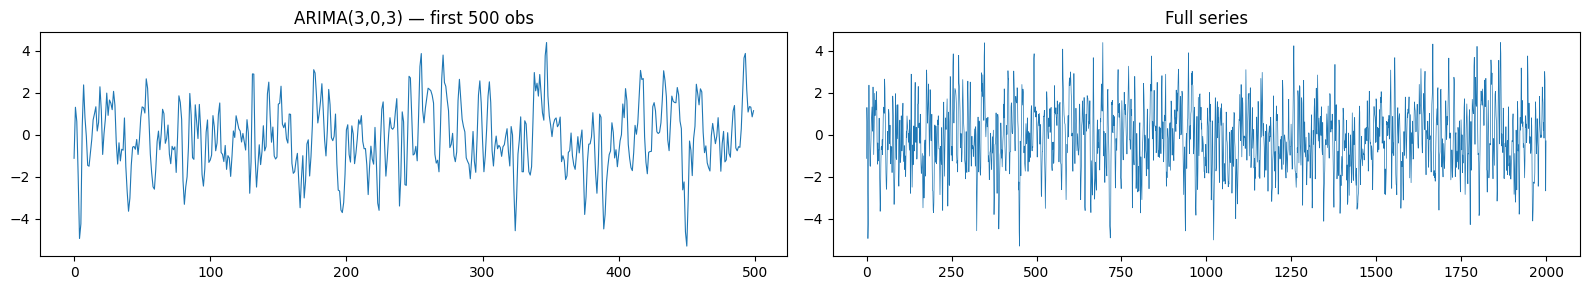

In [4]:
rng = np.random.default_rng(SEED)

# ArmaProcess uses convention: ar = [1, -phi_1, -phi_2, ...]
ar = np.r_[1, -np.array(AR_PARAMS)]
ma = np.r_[1,  np.array(MA_PARAMS)]
process = ArmaProcess(ar, ma)

values = process.generate_sample(nsample=N_OBS, scale=SIGMA, burnin=500,
                                  distrvs=rng.standard_normal)

# attach daily timestamps (frequency doesn't matter for the synthetic test)
dates = pd.date_range('2000-01-01', periods=N_OBS, freq='D')
df    = pd.DataFrame({DATE_COL: dates, TARGET_COL: values})
n     = len(df)

print(f'Generated ARIMA(3,0,3): n={n}, mean={values.mean():.3f}, std={values.std():.3f}')
print(f'AR params: {AR_PARAMS}')
print(f'MA params: {MA_PARAMS}')

fig, axes = plt.subplots(1, 2, figsize=(16, 3))
axes[0].plot(values[:500], linewidth=0.8)
axes[0].set_title('ARIMA(3,0,3) — first 500 obs')
axes[1].plot(values, linewidth=0.5)
axes[1].set_title('Full series')
plt.tight_layout(); plt.show()

## Initialise models

In [5]:
# ── TTM ──────────────────────────────────────────────────────────────────
_ctx         = min(TTM_CONTEXT, K_FIRST)
_init_ctx_df = df.iloc[K_FIRST - _ctx : K_FIRST].copy()

tsp = TimeSeriesPreprocessor(
    timestamp_column=DATE_COL,
    target_columns=[TARGET_COL],
    context_length=_ctx,
    prediction_length=max(HORIZON, 1),
    scaling=True,
    encode_categorical=False,
    scaler_type='standard',
)
tsp = tsp.train(_init_ctx_df)

ttm_model = TinyTimeMixerForPrediction.from_pretrained(
    'ibm-granite/granite-timeseries-ttm-r2',
    revision='512-96-ft-r2.1',
    num_input_channels=tsp.num_input_channels,
)
print('TTM ready')

# ── Traditional forecasters ───────────────────────────────────────────────
traditional = {
    'Naive':     NaiveBenchmarkForecaster(),
    'AR(1)':     ARIMAForecaster(order=(1, 0, 0)),
    'BayesAR':   BayesianARForecaster(p=3, prior_precision=1.0, prior_mode='ridge'),
    'MLBayesAR': MLBayesARForecaster(p=24, prior_mode='minnesota'),
    'SSA':       SSAForecaster(),
}
print(f'Traditional forecasters: {list(traditional.keys())}')

TTM ready
Traditional forecasters: ['Naive', 'AR(1)', 'BayesAR', 'MLBayesAR', 'SSA']


## Rolling-window OOS loop

In [6]:
origins      = list(range(K_FIRST, n - HORIZON + 1))
actuals      = []
origin_dates = []
ttm_preds    = []
trad_preds   = {name: [] for name in traditional}

for k in tqdm(origins, desc='Rolling OOS'):
    actuals.append(values[k + HORIZON - 1])
    origin_dates.append(dates[k])

    # ── TTM — expanding context up to TTM_CONTEXT ─────────────────────────
    ctx_len = min(TTM_CONTEXT, k)
    ctx_df  = df.iloc[k - ctx_len : k].copy().reset_index(drop=True)

    tsp_k = TimeSeriesPreprocessor(
        timestamp_column=DATE_COL,
        target_columns=[TARGET_COL],
        context_length=ctx_len,
        prediction_length=max(HORIZON, 1),
        scaling=True,
        encode_categorical=False,
        scaler_type='standard',
    )
    tsp_k = tsp_k.train(ctx_df)

    pipeline_k = TimeSeriesForecastingPipeline(
        ttm_model,
        device=device,
        feature_extractor=tsp_k,
        batch_size=512,
        add_known_ground_truth=False,
    )

    try:
        fcast    = pipeline_k(ctx_df)
        pred_col = f'{TARGET_COL}_prediction' if f'{TARGET_COL}_prediction' in fcast.columns else TARGET_COL
        pred_arr = np.asarray(fcast.iloc[-1][pred_col], dtype=float)
        ttm_preds.append(pred_arr[HORIZON - 1])
    except Exception:
        ttm_preds.append(np.nan)

    # ── Traditional — capped at TRAD_MAX_HIST ─────────────────────────────
    history = values[max(0, k - TRAD_MAX_HIST) : k]
    for name, fc in traditional.items():
        try:
            pred_arr = fc.fit_predict(history, HORIZON)
            trad_preds[name].append(float(pred_arr[HORIZON - 1]))
        except Exception:
            trad_preds[name].append(np.nan)

actuals      = np.array(actuals, dtype=float)
ttm_preds    = np.array(ttm_preds, dtype=float)
origin_dates = pd.to_datetime(origin_dates)
trad_preds   = {k: np.array(v, dtype=float) for k, v in trad_preds.items()}

print(f'Done. Origins: {len(origins)}')

Rolling OOS:   0%|          | 0/1640 [00:00<?, ?it/s]

Device set to use mps
INFO:p-21678:t-8705831168:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 96, 'context_length': 512, 'frequency_token': 0, 'id_columns': [], 'timestamp_column': 'date', 'target_columns': ['y'], 'observable_columns': [], 'control_columns': [], 'conditional_columns': [], 'categorical_columns': [], 'static_categorical_columns': []}
Device set to use mps
INFO:p-21678:t-8705831168:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 96, 'context_length': 512, 'frequency_token': 0, 'id_columns': [], 'timestamp_column': 'date', 'target_columns': ['y'], 'observable_columns': [], 'control_columns': [], 'conditional_columns': [], 'categorical_columns': [], 'static_categorical_columns': []}
Device set to use mps
INFO:p-21678:t-8705831168:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 96, 'context_length': 512, 'frequency_token': 0, 'id_columns': [], 'timesta

Done. Origins: 1640


## Wrap into BenchmarkResults & run diagnostics

In [11]:
all_preds = {'TTM (granite)': ttm_preds, **trad_preds}
results = BenchmarkResults(
    series_name=f'ARIMA(3,0,3) synthetic (seed={SEED})',
    horizon=HORIZON,
    k_first=K_FIRST,
    forecaster_names=list(all_preds.keys()),
    predictions={k: v.reshape(-1, HORIZON) for k, v in all_preds.items()},
    actuals=actuals.reshape(-1, HORIZON),
)
print(f'BenchmarkResults ready — {results.n_origins} origins, {len(results.forecaster_names)} forecasters')

BenchmarkResults ready — 1640 origins, 6 forecasters


## Summary metrics & scorecard

In [12]:
_sc = results.summary().copy()

_naive_row = _sc[_sc['Forecaster'] == 'Naive']
if not _naive_row.empty:
    _naive_rmse = float(_naive_row['RMSE'].iloc[0])
    _sc['RMSE/Naive'] = _sc['RMSE'] / _naive_rmse if _naive_rmse > 0 else float('nan')
else:
    _sc['RMSE/Naive'] = float('nan')

_num = [c for c in _sc.columns if c != 'Forecaster']
try:
    display(
        _sc.style
        .format({c: '{:.5f}' for c in _num}, na_rep='—')
        .set_properties(subset=_num, **{'text-align': 'right'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}], overwrite=False)
        .background_gradient(subset=['RMSE/Naive'], cmap='RdYlGn_r')
    )
except Exception:
    display(_sc.round(5))

,Forecaster,MSE,MAE,RMSE,RMSE/Naive
0,TTM (granite),1.48137,0.96435,1.21712,0.84140
1,Naive,2.09247,1.15214,1.44654,1.00000
2,AR(1),1.26427,0.89407,1.12440,0.77730
3,BayesAR,1.06349,0.81580,1.03125,0.71291
4,MLBayesAR,1.05564,0.81250,1.02744,0.71028
5,SSA,3.05262,1.39691,1.74717,1.20783


In [9]:
print('── Diebold-Mariano (SE loss) ──')
display(results.diebold_mariano().round(4))

── Diebold-Mariano (SE loss) ──


,Model A,Model B,DM t-stat,DM p-value
0,TTM (granite),Naive,-9.2990,0.0000
1,TTM (granite),AR(1),9.4510,0.0000
2,TTM (granite),BayesAR,10.8066,0.0000
3,TTM (granite),MLBayesAR,11.2093,0.0000
4,TTM (granite),SSA,-13.7619,0.0000
5,Naive,AR(1),11.4013,0.0000
6,Naive,BayesAR,12.9060,0.0000
7,Naive,MLBayesAR,13.0345,0.0000
8,Naive,SSA,-6.9756,0.0000
9,AR(1),BayesAR,7.9928,0.0000


## Charts

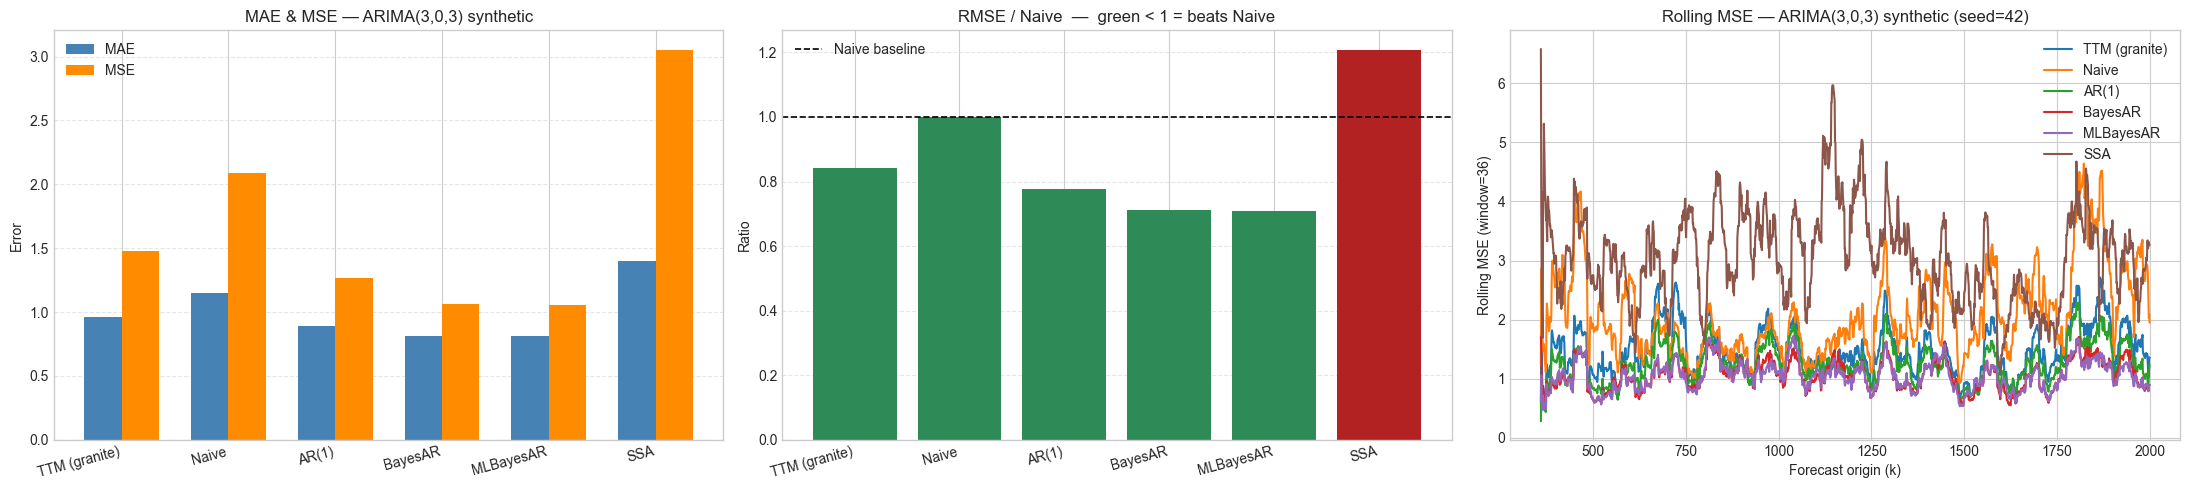

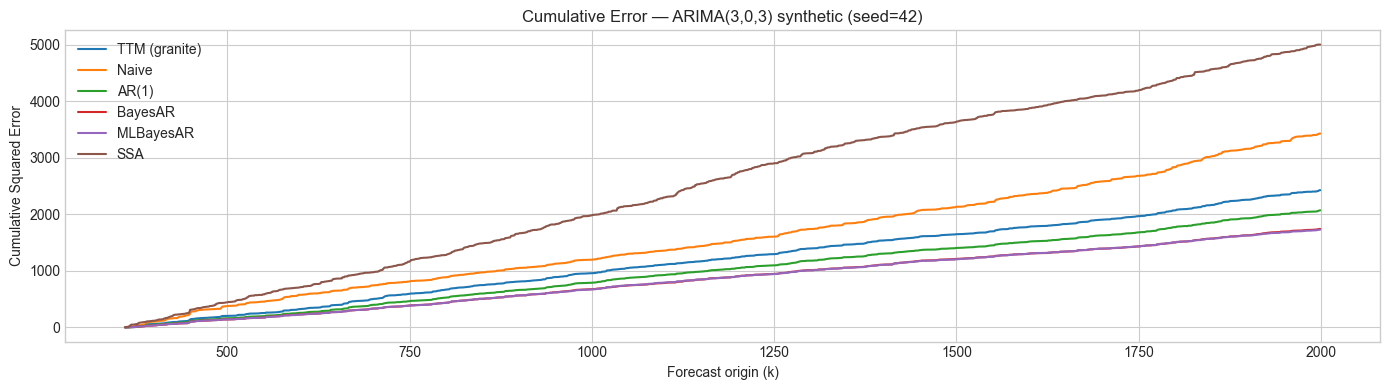

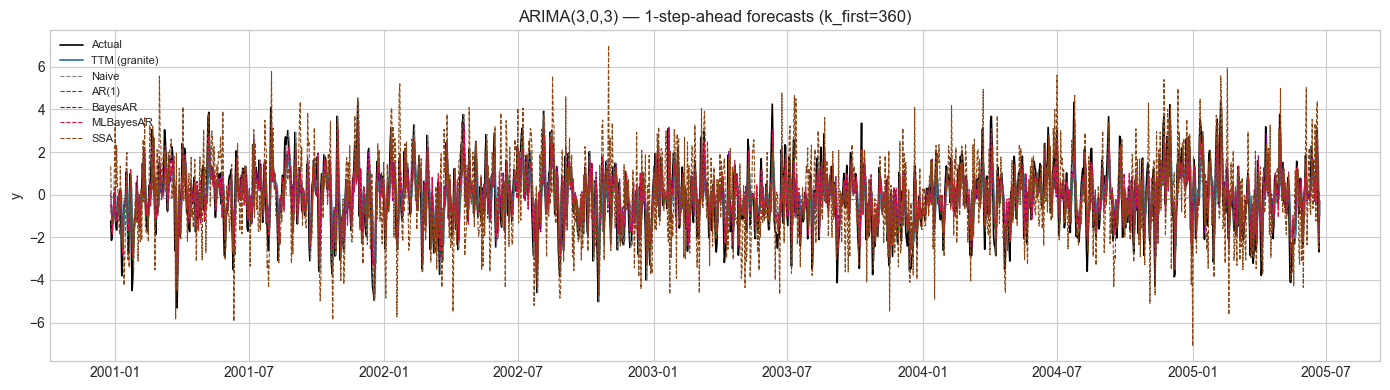

In [10]:
plt.style.use('seaborn-v0_8-whitegrid')

COLORS = {
    'TTM (granite)': 'steelblue',
    'Naive':         'gray',
    'AR(1)':         'green',
    'BayesAR':       'purple',
    'MLBayesAR':     'crimson',
    'SSA':           'saddlebrown',
}

forecaster_names = results.forecaster_names
_x      = np.arange(len(forecaster_names))
_width  = 0.35
_maes   = [float(results.metrics('mae').set_index('Forecaster').loc[n, 'MAE'])  for n in forecaster_names]
_mses   = [float(results.metrics('mse').set_index('Forecaster').loc[n, 'MSE'])  for n in forecaster_names]
_ratios = _sc.set_index('Forecaster').loc[forecaster_names, 'RMSE/Naive'].fillna(1.0).tolist()
_rcolors = ['seagreen' if v <= 1.0 else 'firebrick' for v in _ratios]

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

axes[0].bar(_x - _width/2, _maes, _width, label='MAE', color='steelblue')
axes[0].bar(_x + _width/2, _mses, _width, label='MSE', color='darkorange')
axes[0].set_xticks(_x); axes[0].set_xticklabels(forecaster_names, rotation=15, ha='right')
axes[0].set_title('MAE & MSE — ARIMA(3,0,3) synthetic')
axes[0].set_ylabel('Error'); axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].bar(_x, _ratios, color=_rcolors)
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='Naive baseline')
axes[1].set_xticks(_x); axes[1].set_xticklabels(forecaster_names, rotation=15, ha='right')
axes[1].set_title('RMSE / Naive  —  green < 1 = beats Naive')
axes[1].set_ylabel('Ratio'); axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

results.plot_mse_over_time(rolling_window=ROLLING_WINDOW, ax=axes[2])

plt.tight_layout(); plt.show()

fig2, ax2 = plt.subplots(figsize=(14, 4))
results.plot_cumulative_error(ax=ax2)
plt.tight_layout(); plt.show()

fig3, ax3 = plt.subplots(figsize=(14, 4))
ax3.plot(origin_dates, actuals, label='Actual', color='black', linewidth=1.2)
for name in forecaster_names:
    preds = results.predictions[name].ravel()
    lw = 1.4 if name == 'TTM (granite)' else 0.8
    ls = '-'  if name == 'TTM (granite)' else '--'
    ax3.plot(origin_dates, preds, label=name, color=COLORS.get(name, 'steelblue'), linewidth=lw, linestyle=ls)
ax3.set_title(f'ARIMA(3,0,3) — {HORIZON}-step-ahead forecasts (k_first={K_FIRST})')
ax3.legend(fontsize=8); ax3.set_ylabel('y')
plt.tight_layout(); plt.show()